# Lab 5.0 — Eigenvalue and Eigenvector
**Linear Algebra and Statistics | Institute of Technology of Cambodia**  
Instructor: PHAUK Sokkhey, Ph.D

---

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## 1. Eigenvalues and Eigenvectors

For a square matrix $A$, the scalar $\lambda$ is an **eigenvalue** and the nonzero vector $\mathbf{x}$ is the corresponding **eigenvector** if:
$$A\mathbf{x} = \lambda \mathbf{x}$$

Use `np.linalg.eig(A)` to compute both at once.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Example (lecture slide 6): A = [[1,-2,1],[0,0,0],[0,1,1]]
A = np.array([[1, -2, 1],
              [0,  0, 0],
              [0,  1, 1]], dtype=float)

eigenvalues, eigenvectors = np.linalg.eig(A)

print("Eigenvalues:", np.round(eigenvalues, 4))
print("Eigenvectors (columns):")
print(np.round(eigenvectors, 4))

# Verify: A @ x == lambda * x  for each pair
print("\nVerification  A@x ≈ λ·x:")
for i in range(len(eigenvalues)):
    lam = eigenvalues[i] #lam = lamda
    x   = eigenvectors[:, i]
    ok  = np.allclose(A @ x, lam * x)
    print(f"  λ={lam:.2f}  ✅" if ok else f"  λ={lam:.2f}  ❌")

Eigenvalues: [1. 1. 0.]
Eigenvectors (columns):
[[ 1.     -1.      0.9045]
 [ 0.      0.      0.3015]
 [ 0.      0.     -0.3015]]

Verification  A@x ≈ λ·x:
  λ=1.00  ✅
  λ=1.00  ✅
  λ=0.00  ✅


## 2. Diagonalization

An $n\times n$ matrix $A$ is **diagonalizable** if there exists an invertible matrix $P$ such that:
$$D = P^{-1}AP$$
where $D$ is diagonal. The columns of $P$ are the eigenvectors, and the diagonal entries of $D$ are the eigenvalues.

In [3]:
# Example (lecture slide 18): A = [[1,3,0],[3,1,0],[0,0,-2]]
A = np.array([[1,  3,  0],
              [3,  1,  0],
              [0,  0, -2]], dtype=float)

eigenvalues, P = np.linalg.eig(A)
D = np.linalg.inv(P) @ A @ P

print("Eigenvalues:", np.round(eigenvalues, 4))
print("\nP (eigenvectors as columns):")
print(np.round(P, 4))
print("\nD = P⁻¹AP (should be diagonal):")
print(np.round(D, 4))

Eigenvalues: [ 4. -2. -2.]

P (eigenvectors as columns):
[[ 0.7071 -0.7071  0.    ]
 [ 0.7071  0.7071  0.    ]
 [ 0.      0.      1.    ]]

D = P⁻¹AP (should be diagonal):
[[ 4. -0.  0.]
 [-0. -2.  0.]
 [ 0.  0. -2.]]


## 3. Visualizing Eigenvectors (2×2 case)

Eigenvectors are the directions that a matrix only **stretches or flips**, never rotates.

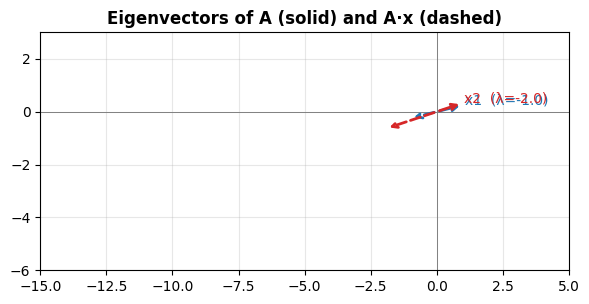

In [4]:
# A = [[2,-12],[1,-5]]  (lecture slide 11)
A = np.array([[2, -12],
              [1,  -5]], dtype=float)

eigenvalues, eigenvectors = np.linalg.eig(A)

fig, ax = plt.subplots(figsize=(6, 5))
colors = ["tab:blue", "tab:red"]

for i in range(2):
    v  = eigenvectors[:, i].real
    Av = A @ v
    lam = eigenvalues[i].real
    ax.annotate("", xy=v,  xytext=(0,0), arrowprops=dict(arrowstyle="->", color=colors[i], lw=2))
    ax.annotate("", xy=Av, xytext=(0,0), arrowprops=dict(arrowstyle="->", color=colors[i], lw=2, linestyle="dashed"))
    ax.text(v[0]*1.1, v[1]*1.1, f"x{i+1}  (λ={lam:.1f})", color=colors[i], fontsize=10)

ax.axhline(0, color="gray", lw=0.7)
ax.axvline(0, color="gray", lw=0.7)
ax.set_xlim(-15, 5); ax.set_ylim(-6, 3)
ax.set_aspect("equal"); ax.grid(True, alpha=0.3)
ax.set_title("Eigenvectors of A (solid) and A·x (dashed)", fontweight="bold")
plt.tight_layout(); plt.show()

---
## ✏️ To-Do Exercises

### Exercise 1
For the matrix below, find the eigenvalues and eigenvectors using `np.linalg.eig`, then verify that $A\mathbf{x} = \lambda\mathbf{x}$ holds for each pair.

$$A = \begin{bmatrix} -2 & 2 & -3 \\ 2 & 1 & -6 \\ -1 & -2 & 0 \end{bmatrix}$$

*(From TD exercise 1(d): expected eigenvalues are 5, −3, −3)*

In [9]:
# Exercise 1 — your code here
A = np.array([[-2,  2, -3],
              [ 2,  1, -6],
              [-1, -2,  0]], dtype=float)

# Compute eigenvalues and eigenvectors
eigenvalues, eigenvectors = np.linalg.eig(A)

#print the eigen value and eigen vector
print("Eigenvalues:", np.round(eigenvalues, 4))
print("Eigenvectors (columns):")
print(np.round(eigenvectors, 4))

# Verify: A @ x == lambda * x  for each pair
print("\nVerification  A@x ≈ λ·x:")
for i in range(len(eigenvalues)):
    lam = eigenvalues[i] #lam = lamda
    x   = eigenvectors[:, i]
    ok  = np.allclose(A @ x, lam * x)
    print(f"  λ={lam:.2f}  ✅" if ok else f"  λ={lam:.2f}  ❌")



Eigenvalues: [-3.  5. -3.]
Eigenvectors (columns):
[[-0.9526  0.4082 -0.023 ]
 [ 0.2722  0.8165  0.8353]
 [-0.1361 -0.4082  0.5492]]

Verification  A@x ≈ λ·x:
  λ=-3.00  ✅
  λ=5.00  ✅
  λ=-3.00  ✅


### Exercise 2
Diagonalize the matrix below: find $P$ and $D = P^{-1}AP$, and verify that $D$ is diagonal.

$$A = \begin{bmatrix} 4 & -5 \\ 2 & -3 \end{bmatrix}$$

*(From TD exercise 9(d): expected eigenvalues are −1 and 2)*

In [ ]:
# Exercise 2 — your code here
A = np.array([[4, -5],
              [2, -3]], dtype=float)

# Find eigenvalues and P
eigenvalues, P = np.linalg.eig(A)
# Compute D = P^{-1} A P
D = np.linalg.inv(P) @ A @ P
# Print results
print("Eigenvalues:", np.round(eigenvalues, 4))
print("\nP (eigenvectors as columns):")
print(np.round(P, 4))
print("\nD = P⁻¹AP (should be diagonal):")
print(np.round(D, 4))


Eigenvalues: [ 2. -1.]

P (eigenvectors as columns):
[[0.9285 0.7071]
 [0.3714 0.7071]]

D = P⁻¹AP (should be diagonal):
[[ 2.  0.]
 [-0. -1.]]


---
*Lab 5.0 — Linear Algebra and Statistics, ITC*